# [Background Estimation (`photutils.background`)](https://photutils.readthedocs.io/en/latest/user_guide/background.html)

# Scalar Background and Noise Estimation

## Simple Statistics

In [23]:
from photutils.datasets import make_100gaussians_image 
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

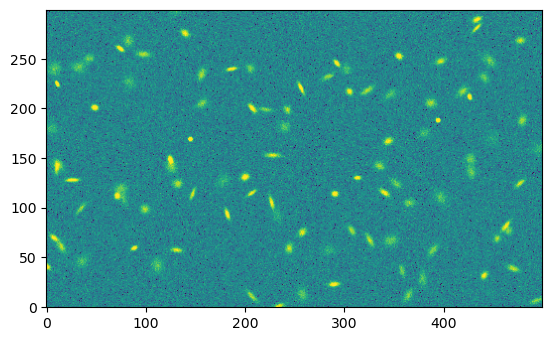

In [48]:
data = make_100gaussians_image()
    # Executa a função e armazena a imagem gerada em um array NumPy 2D chamado data.
    # A imagem tem dimensões padrão (geralmente 512×512 pixels) e contém as 100 fontes gaussianas mais um fundo com ruído.

norm = simple_norm(data, 'sqrt', percent=99.5)
    # normalização -> define qual valor vira qual cor:
    # sem normalização -> usa o mínimo e máximo da imagem
    # com normalização -> você pode destacar detalhes em partes escuras, cortar outliers, etc

    # sqrt -> usa a raiz quadrada como função de escala (realça partes escuras sem saturar as brilhantes)
    # percent=99.5 -> corta os 0.5% dos pixels mais intensos (outliers) para evitar que pontos muito brilhantes dominem a visualização.

fig, ax = plt.subplots()
ax.imshow(data, norm=norm, origin='lower')

In [25]:
import numpy as np
from astropy.stats import biweight_location

print(np.median(data))
print(biweight_location(data))

5.222396450477202
5.187556943476142


In [26]:
from astropy.stats import mad_std
print(mad_std(data))

2.1497096320053166


## Sigma Clipping Sources

In [27]:
from astropy.stats import sigma_clipped_stats

mean, median, std = sigma_clipped_stats(data, sigma=3.0)
print(np.array((mean, median, std)))

[5.19968673 5.15244174 2.09423739]


# Masking Sources 

In [28]:
from astropy.stats import sigma_clipped_stats, SigmaClip
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint

sigma_clip = SigmaClip(sigma=3.0, maxiters=10)
    # remover outliers 
    # sigma=3.0 -> pixels com valor > 3 desvios padrão da mediana são considerados outliers
    # maxiters=10 -> repete o processo no máximo 10 vezes (ou até que não tenha mais outliers)

threshold = detect_threshold(data, nsigma=2.0, sigma_clip=sigma_clip)
    # cálculo do limiar:
    # n_sigma=2.0 -> o limiar será = mediana do fundo + (2 × desvio padrão do fundo)
    # sigma_clip ->  estima a mediana e o desvio do fundo de forma robusta (sem ser afetado pelas fontes brilhantes)
    # retorna um array 2D com os valores de limiar para cada pixel

segment_img = detect_sources(data, threshold, npixels=10)
    # detecção das fontes:
    # threshold -> o limiar calculado acima.
    # n_pixels=10 > número mínimo de pixels conectados para considerar um grupo como fonte (evita ruído)
    # retorna um objeto SegmentImage onde cada fonte tem um número inteiro único (rótulo)

footprint = circular_footprint(radius=10)
    # cria uma máscara booleana circular de raio = 10 pixels
    # isso define a forma de como vai ser 'cercada 'cada fonte para extrair seus pixels

mask= segment_img.make_source_mask(footprint=footprint)
    # gera uma máscara booleana 2D onde:
    # se houver fontes detectadas, a máscara marca uma região circular (usando a footprint) ao redor de cada fonte
    # o objetivo é isolar as fontes para que possamos calcular estatísticas apenas do fundo (excluindo as fontes)

mean, median, std = sigma_clipped_stats(data, sigma=3.0, mask=mask)
    # estatísticas

print(np.array((mean, median, std)))

[5.00257401 4.99641799 1.97009566]


# 2D Background and Noise Estimation

For this example, we will create a test image by adding a strong background gradient to the image defined above:

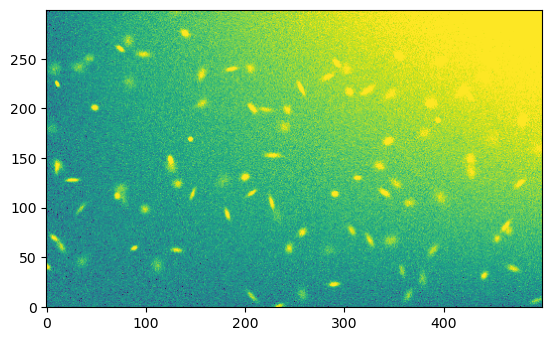

In [29]:
ny, nx = data.shape
y, x = np.mgrid[:ny, :nx]
gradient = x*y / 5000.0
data2 = data + gradient
fig, ax = plt.subplots()
ax.imshow(data2, norm=norm, origin='lower')

We start by creating a [Background2D](https://photutils.readthedocs.io/en/latest/api/photutils.background.Background2D.html#photutils.background.Background2D) object using a box size of 15x15 and a 3x3 median filter. We will estimate the background level in each mesh as the sigma-clipped median using an instance of [MedianBackground](https://photutils.readthedocs.io/en/latest/api/photutils.background.MedianBackground.html#photutils.background.MedianBackground):

In [30]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground

sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg = Background2D(data2, (15, 15), filter_size=(3, 3),
                  sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

The 2D background and background RMS images are retrieved using the `background` and `background_rms` attributes, respectively, on the returned object. The low-resolution versions of these images are stored in the `background_mesh` and `background_rms_mesh` attributes, respectively. The global median value of the low-resolution background and background RMS image can be accessed with the `background_median` and `background_rms_median` attributes, respectively:

In [31]:
print(bkg.background_median)
print(round(bkg.background_rms_median, 4))

10.822232525276007
2.0367


Let’s plot the background image:

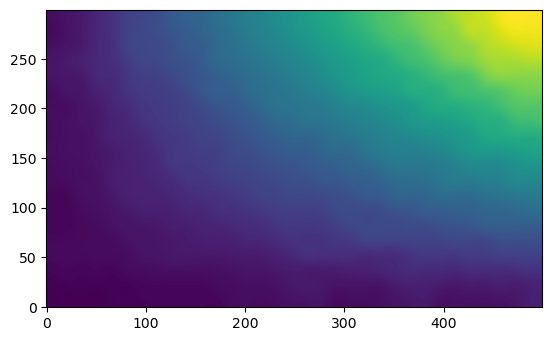

In [32]:
fig, ax = plt.subplots()
ax.imshow(bkg.background, origin='lower')

and the background-subtracted image:

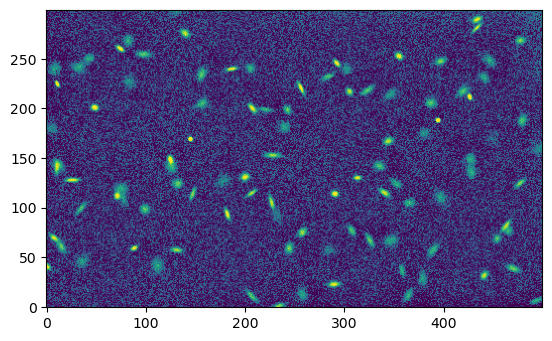

In [33]:
data2_sub = data2 - bkg.background
fig, ax = plt.subplots()
ax.imshow(data2_sub, norm=norm, origin='lower')

# Masking

Let’s create a rotated image that has blank areas and plot it:

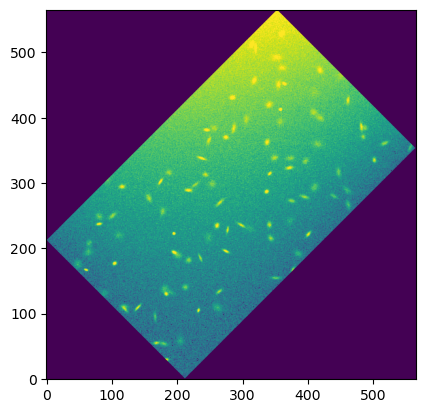

In [45]:
from astropy.visualization import simple_norm, ImageNormalize, SqrtStretch
from scipy.ndimage import rotate

data3 = rotate(data2, -45.0)
norm = simple_norm(data3, 'sqrt', percent=99.5)

fig, ax = plt.subplots()
ax.imshow(data3, norm=norm, origin='lower')

Now we create a coverage mask and input it into [Background2D](https://photutils.readthedocs.io/en/latest/api/photutils.background.Background2D.html#photutils.background.Background2D) to exclude the regions where we have no data. For this example, we set the `fill_value` to 0.0. For real data, one can usually create a coverage mask from a weight or noise image. In this example we also use a smaller box size to help capture the strong gradient in the background. We also increase the value of the `exclude_percentile` keyword to include more boxes around the edge of the rotated image:

In [38]:
coverage_mask = (data3 == 0)
bkg3 = Background2D(data3, 
                   (15, 15), 
                   filter_size=(3, 3),
                  coverage_mask=coverage_mask, 
                   fill_value=0.0, 
                   exclude_percentile=50.0)

Note that the `coverage_mask` is applied to the output background image (values assigned to `fill_value`):

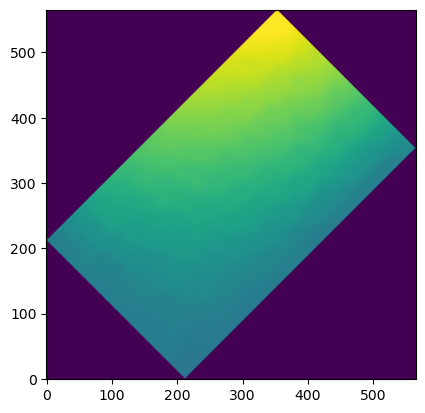

In [39]:
norm = simple_norm(bkg3.background, 'sqrt', percent=99.5)
fig, ax = plt.subplots()
ax.imshow(bkg3.background, norm=norm, origin='lower')

Finally, let’s subtract the background from the image and plot it:

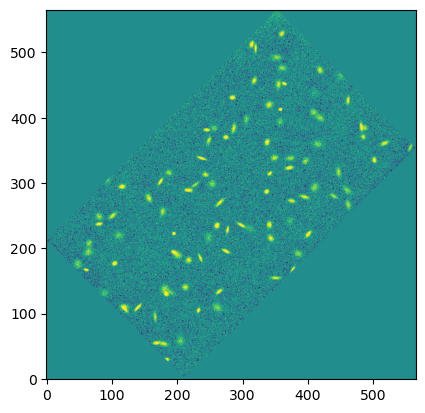

In [46]:
norm = ImageNormalize(stretch=SqrtStretch())
data_sub = data3 - bkg3.background
norm = simple_norm(data_sub, 'sqrt', percent=99.5)

fig, ax = plt.subplots()
ax.imshow(data_sub, norm=norm, origin='lower')

If there is any small residual background still present in the image, the background subtraction can be improved by masking the sources and/or through further iterations.

## Ploting Meshes

Finally, the meshes that were used in generating the 2D background can be plotted on the original image using the [plot_meshes()](https://photutils.readthedocs.io/en/latest/api/photutils.background.Background2D.html#photutils.background.Background2D.plot_meshes) method. Here we zoom in on a small portion of the image to show the background meshes. Meshes without a center marker were excluded.

(0.0, 250.0)

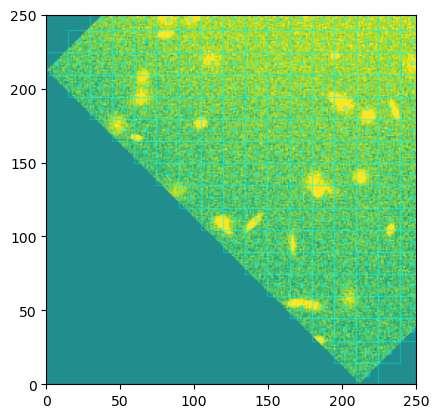

In [47]:
fig, ax = plt.subplots()
ax.imshow(data3, norm=norm, origin='lower')

bkg3.plot_meshes(outlines=True, marker='.', color='cyan', alpha=0.3)

ax.set_xlim(0, 250)
ax.set_ylim(0 ,250)

# API Reference

[Backgrounds (photutils.background)](https://photutils.readthedocs.io/en/latest/reference/background_api.html)